In [274]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pynapple as nap
import seaborn as sns

from nrem_analysis.constant import MOUSE_IDS_TTX, PROCESSED_DIR


TURN_THRESHOLD = 100  # deg/s


def epoch_velocities(angles, epochs):
    """Unwrap angles in radians within each epoch and return mean velocities in deg/s."""
    velocities = []

    for start, end in epochs.values:
        unwrapped_angles = np.unwrap(angles.get(start, end).values)
        displacement = np.rad2deg(unwrapped_angles[-1] - unwrapped_angles[0])
        velocities.append(displacement / (end - start))

    return np.array(velocities)


def detect_upstates(spikes):
    bin_size = 0.01
    spike_counts = spikes.count(bin_size=bin_size, time_units="s")
    population_rate = spike_counts.sum(axis=1) / bin_size
    population_rate = population_rate.smooth(std=2 * bin_size, time_units="s")
    threshold = np.percentile(population_rate.values, 80)

    upstates = population_rate.threshold(threshold, method="above").time_support
    upstates = upstates.merge_close_intervals(0.1, time_units="s")
    upstates = upstates.drop_short_intervals(0.04, time_units="s")
    return upstates.drop_long_intervals(2, time_units="s")

In [280]:
bout_rows = []

for mouse_id in MOUSE_IDS_TTX:
    data_dir = PROCESSED_DIR / "ttx" / mouse_id
    sessions = nap.load_file(data_dir / "sessions.npz")
    ttx_onset = sessions[sessions["label"] == "ttx"].start.item()

    sleep = nap.load_file(data_dir / "sleep.npz")
    hd_units = nap.load_file(data_dir / "hd_units.npz")
    virtual_hd = np.deg2rad(nap.load_file(data_dir / "virtual_hd.npz"))

    homecage = sessions[sessions["label"] == "homecage"]
    nrem = sleep[sleep["state"] == "nrem"].intersect(homecage)
    upstates = detect_upstates(hd_units.restrict(nrem))

    for bout_index, nrem_bout in enumerate(nrem):
        if nrem_bout.tot_length() < 60:
            continue

        bout_upstates = upstates.intersect(nrem_bout)
        velocities = epoch_velocities(virtual_hd, bout_upstates)
        cw_count = np.sum(velocities > TURN_THRESHOLD)
        ccw_count = np.sum(velocities < -TURN_THRESHOLD)

        bout_rows.append({
            "mouse_id": mouse_id,
            "bout": bout_index,
            "condition": "ttx" if nrem_bout.start.item() > ttx_onset else "control",
            "velocity": velocities.mean(),
            "ratio": np.log(cw_count / ccw_count),
        })

results = pd.DataFrame(bout_rows)
mouse_means = results.groupby(["mouse_id", "condition"], as_index=False)[["velocity", "ratio"]].mean()

In [310]:
results.groupby('condition').size()

condition
control    136
ttx        372
dtype: int64

In [ ]:
mouse_means

,mouse_id,condition,velocity,ratio
0,116b,control,-50.988410,0.025216
1,116b,ttx,27.777830,0.093422
2,119b,control,-28.434528,-0.195848
3,119b,ttx,5.301976,-0.006131
4,83b,control,42.792145,0.090172
5,83b,ttx,75.177002,0.173939
6,85b,control,-12.247334,-0.182867
7,85b,ttx,42.717685,0.129748


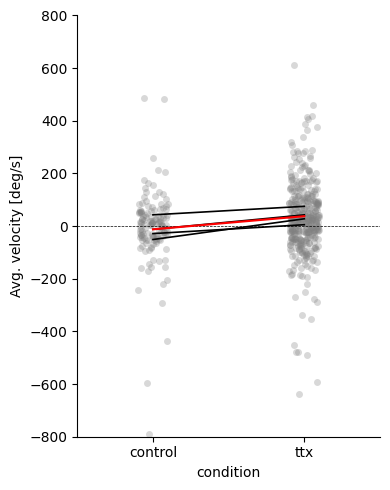

In [306]:
mouse_palette = {mouse_id: "black" for mouse_id in MOUSE_IDS_TTX}

stripplot_kwargs = dict(
    data=results,
    x="condition",
    order=["control", "ttx"],
    c="0.5", alpha=0.3, zorder=0
)
pointplot_kwargs = dict(
    data=mouse_means,
    x="condition",
    order=["control", "ttx"],
    errorbar=None,
    markersize=0,
)

fig, ax = plt.subplots(figsize=(4, 5))

sns.stripplot(y="velocity", ax=ax, **stripplot_kwargs)
sns.pointplot(
    y="velocity", ax=ax, hue="mouse_id", palette=mouse_palette,
    legend=False, lw=1.2, **pointplot_kwargs,
)
sns.pointplot(
    y="velocity", ax=ax, c="r", lw=1.5, zorder=3, **pointplot_kwargs,
)
ax.set_ylabel("Avg. velocity [deg/s]")
ax.set_ylim(-800, 800)
ax.axhline(0, lw=0.5, ls="--", c="k")

sns.despine()
fig.tight_layout()

plt.savefig(FIGURES_DIR / "ttx" / "bout_velocity.png", format='png', bbox_inches='tight')
plt.savefig(FIGURES_DIR / "ttx" / "bout_velocity.svg", format='svg', bbox_inches='tight')

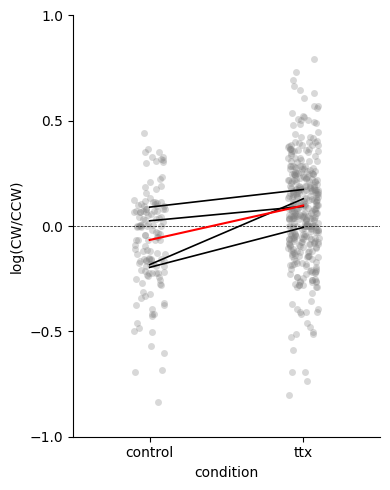

In [308]:
fig, ax = plt.subplots(figsize=(4, 5))

sns.stripplot(y="ratio", ax=ax, **stripplot_kwargs)
sns.pointplot(
    y="ratio", ax=ax, hue="mouse_id", palette=mouse_palette,
    legend=False, lw=1.2, **pointplot_kwargs,
)
sns.pointplot(
    y="ratio", ax=ax, c="r", lw=1.5, zorder=3, **pointplot_kwargs,
)
ax.set_ylabel("log(CW/CCW)")
ax.set_ylim(-1, 1)
ax.set_yticks((-1, -0.5, 0, 0.5, 1))
ax.axhline(0, lw=0.5, ls="--", c="k")

sns.despine()
fig.tight_layout()

plt.savefig(FIGURES_DIR / "ttx" / "bout_ratio.png", format='png', bbox_inches='tight')
plt.savefig(FIGURES_DIR / "ttx" / "bout_ratio.svg", format='svg', bbox_inches='tight')